#Lab: Residual Networks — MLP (MNIST1D) to 1D Conv and 2D Conv **Total: 10 marks**

#**Overview:**
# - This notebook provides a working PyTorch boilerplate implementing a residual MLP trained on a 1D version of MNIST (MNIST1D).
# - You will extend the code to (a) a residual 1D convolutional network and (b) a residual 2D convolutional network.
# - For the 1D conv task, use the provided *MNIST1D* representation (treat each image as a 1×784 1D signal).
# - For the 2D conv task, use **CIFAR-10** (32×32 RGB) as the dataset.

# Hints:
# - Keep residual blocks simple (Conv-BN-ReLU -> Conv-BN + skip -> ReLU).
# - For 1D conv: use `nn.Conv1d` with input channel 1 and kernel sizes like 3 or 5.
# - For 2D conv: start from a small ResNet-like block (use stride 1 / 2 when downsampling).
# - Use `torchvision.datasets.MNIST` for MNIST1D (reshape) and `torchvision.datasets.CIFAR10` for CIFAR-10.
# - Use SGD/Adam, and train for a small number of epochs first (e.g., 10) to validate your pipeline.

In [1]:
# Standard imports and utilities
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms
import time
import matplotlib.pyplot as plt


# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cuda


In [2]:
# %%
def set_seed(seed=42):
  import random, numpy as np
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

set_seed()

In [16]:
# Simple training loop
def train_one_epoch(model, loader, criterion, optimizer, device):
  model.train()
  running_loss = 0.0
  correct = 0
  total = 0
  for x, y in loader:
    x = x.to(device)
    y = y.to(device)
    optimizer.zero_grad()
    out = model(x)
    loss = criterion(out, y)
    loss.backward()
    optimizer.step()
    running_loss += loss.item() * x.size(0)
    _, preds = out.max(1)
    correct += (preds == y).sum().item()
    total += x.size(0)
  return running_loss / total, correct / total

def evaluate(model, loader, criterion, device):
  model.eval()
  running_loss = 0.0
  correct = 0
  total = 0
  with torch.no_grad():
    for x, y in loader:
      x = x.to(device)
      y = y.to(device)
      out = model(x)
      loss = criterion(out, y)
      running_loss += loss.item() * x.size(0)
      _, preds = out.max(1)
      correct += (preds == y).sum().item()
      total += x.size(0)
  return running_loss / total, correct / total

In [4]:
# Plotting utility
def plot_curves(hist, title=None):
    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.plot(hist['train_loss'], label='train_loss')
    plt.plot(hist['val_loss'], label='val_loss')
    plt.legend()
    plt.grid(True)
    plt.subplot(1,2,2)
    plt.plot(hist['train_acc'], label='train_acc')
    plt.plot(hist['val_acc'], label='val_acc')
    plt.legend()
    plt.grid(True)
    if title: plt.suptitle(title)
    plt.show()

In [5]:
# Data: MNIST1D loaders
batch_size = 128
transform_mnist = transforms.Compose([
transforms.ToTensor(),
# We'll flatten in the dataset transform step below
])

trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transform_mnist)
testset = datasets.MNIST(root='./data', train=False, download=True, transform=transform_mnist)

100%|██████████| 9.91M/9.91M [00:00<00:00, 59.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.71MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.7MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.10MB/s]


In [6]:
# Wrap to reshape images into (1, 784)
class MNIST1D(Dataset):
  def __init__(self, base_dataset):
    self.base = base_dataset
  def __len__(self):
    return len(self.base)
  def __getitem__(self, idx):
    x, y = self.base[idx]
    # x shape: [1, 28, 28] -> reshape to [1, 784]
    x = x.view(1, -1)
    return x, y

train_loader_1d = DataLoader(MNIST1D(trainset), batch_size=batch_size, shuffle=True, num_workers=2)
test_loader_1d = DataLoader(MNIST1D(testset), batch_size=batch_size, shuffle=False, num_workers=2)

In [7]:
# Residual MLP boilerplate
class ResidualMLP(nn.Module):
  def __init__(self, in_features=784, hidden=512, n_classes=10):
    super().__init__()
    self.fc1 = nn.Linear(in_features, hidden)
    self.bn1 = nn.BatchNorm1d(hidden)
    self.fc2 = nn.Linear(hidden, hidden)
    self.bn2 = nn.BatchNorm1d(hidden)
    self.fc_out = nn.Linear(hidden, n_classes)


  def forward(self, x):
    # x: [B, 1, 784]
    x = x.squeeze(1) # -> [B, 784]
    h = F.relu(self.bn1(self.fc1(x)))
    h2 = self.bn2(self.fc2(h))
    h = F.relu(h + h2) # residual connection across two linear layers
    out = self.fc_out(h)
    return out

#1) We treat each MNIST image (28×28) as a flattened 1×784 1D signal. The provided MLP has a residual connection across two linear layers.
#
# **Task:** Run the cells below to get a baseline test accuracy. Finetune hyperparameters. (2 marks)

Epoch 1/5 — train_loss: 2.4078, train_acc: 0.1771, val_acc: 0.4699, time: 9.1s
Epoch 2/5 — train_loss: 1.2808, train_acc: 0.7500, val_acc: 0.6048, time: 9.3s
Epoch 3/5 — train_loss: 0.8796, train_acc: 0.7500, val_acc: 0.7039, time: 10.6s
Epoch 4/5 — train_loss: 0.7864, train_acc: 0.8021, val_acc: 0.7394, time: 8.4s
Epoch 5/5 — train_loss: 0.9193, train_acc: 0.7500, val_acc: 0.7346, time: 9.3s

Baseline test evaluation:
Test loss: 1.8054, Test accuracy: 0.7346


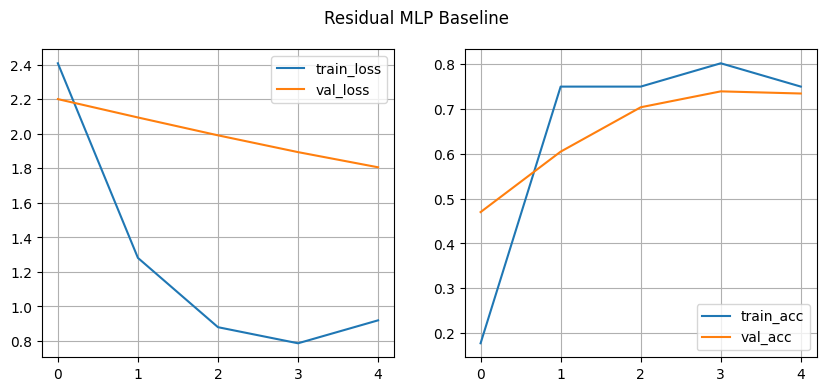

In [11]:
# Train the MLP baseline for a few epochs (students can run longer for better accuracy)
model_mlp = ResidualMLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_mlp.parameters(), lr=1e-3)

hist = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

n_epochs = 20 # baseline quick run; extend to 10-20 as needed
for epoch in range(n_epochs):
  t0 = time.time()
  train_loss, train_acc = train_one_epoch(model_mlp, train_loader_1d, criterion, optimizer, device)
  val_loss, val_acc = evaluate(model_mlp, test_loader_1d, criterion, device)
  hist['train_loss'].append(train_loss)
  hist['val_loss'].append(val_loss)
  hist['train_acc'].append(train_acc)
  hist['val_acc'].append(val_acc)
  print(f"Epoch {epoch+1}/{n_epochs} — train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, val_acc: {val_acc:.4f}, time: {time.time()-t0:.1f}s")


print('\nBaseline test evaluation:')
val_loss, val_acc = evaluate(model_mlp, test_loader_1d, criterion, device)
print(f'Test loss: {val_loss:.4f}, Test accuracy: {val_acc:.4f}')
plot_curves(hist, title='Residual MLP Baseline')

Original Evaluation: Test loss: 1.7927, Test accuracy: 0.7314


# 2)**Goal (3 marks):** Replace the MLP with a residual 1D conv network and train on MNIST1D (same dataset as above). Use `nn.Conv1d` layers and residual connections similar to a small ResNet block.
#
# **Dataset:** Use MNIST (reshaped to 1×784) — i.e., `MNIST1D` loader above.
#
# **Requirements:**
# - Implement a Residual1D class below. It should accept input with shape `[B, 1, 784]`.
# - Use at least two residual blocks. If necessary, change number of channels using 1×1 conv for the skip connection.
# - Train for at least 10 epochs and report final test accuracy and loss curves.
#

In [17]:
class ResidualBlock1D(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels, out_channels, kernel_size, stride=stride, padding=kernel_size//2)
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.conv2 = nn.Conv1d(out_channels, out_channels, kernel_size, stride=1, padding=kernel_size//2)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.skip = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else nn.Identity()

    def forward(self, x):
        identity = self.skip(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = F.relu(out + identity)
        return out

In [18]:
class Residual1D(nn.Module):
    def __init__(self, in_channels=1, num_classes=10):
        super().__init__()
        self.block1 = ResidualBlock1D(in_channels, 32, kernel_size=5)
        self.block2 = ResidualBlock1D(32, 64, kernel_size=5)
        self.pool = nn.AdaptiveAvgPool1d(1)  # global average pooling
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.pool(x).squeeze(-1)
        out = self.fc(x)
        return out

Epoch 1/10 — train_loss: 1.4581, train_acc: 0.5363, val_acc: 0.6188, time: 12.5s
Epoch 2/10 — train_loss: 0.9757, train_acc: 0.7036, val_acc: 0.5784, time: 12.4s
Epoch 3/10 — train_loss: 0.8326, train_acc: 0.7449, val_acc: 0.7394, time: 12.5s
Epoch 4/10 — train_loss: 0.7559, train_acc: 0.7655, val_acc: 0.5841, time: 12.4s
Epoch 5/10 — train_loss: 0.7133, train_acc: 0.7787, val_acc: 0.7119, time: 12.4s
Epoch 6/10 — train_loss: 0.6818, train_acc: 0.7891, val_acc: 0.7563, time: 12.5s
Epoch 7/10 — train_loss: 0.6616, train_acc: 0.7942, val_acc: 0.6933, time: 12.4s
Epoch 8/10 — train_loss: 0.6405, train_acc: 0.7991, val_acc: 0.5846, time: 12.6s
Epoch 9/10 — train_loss: 0.6265, train_acc: 0.8043, val_acc: 0.5836, time: 12.5s
Epoch 10/10 — train_loss: 0.6141, train_acc: 0.8092, val_acc: 0.7130, time: 12.4s

Final Test Loss: 0.8511, Test Accuracy: 0.7130


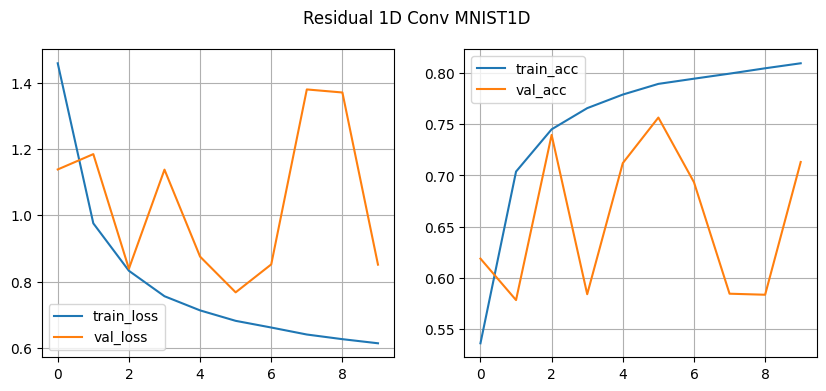

In [19]:
# model_1d = Residual1D().to(device)
# criterion = nn.CrossEntropyLoss()
# optimizer = torch.optim.Adam(model_1d.parameters(), lr=1e-3)

# n_epochs = 10
# hist_1d = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[]}

# for epoch in range(n_epochs):
#     t0 = time.time()
#     train_loss, train_acc = train_one_epoch(model_1d, train_loader_1d, criterion, optimizer, device)
#     val_loss, val_acc = evaluate(model_1d, test_loader_1d, criterion, device)

#     hist_1d['train_loss'].append(train_loss)
#     hist_1d['val_loss'].append(val_loss)
#     hist_1d['train_acc'].append(train_acc)
#     hist_1d['val_acc'].append(val_acc)

#     print(f"Epoch {epoch+1}/{n_epochs} — train_loss: {train_loss:.4f}, train_acc: {train_acc:.4f}, val_acc: {val_acc:.4f}, time: {time.time()-t0:.1f}s")

# val_loss, val_acc = evaluate(model_1d, test_loader_1d, criterion, device)
# print(f'\nFinal Test Loss: {val_loss:.4f}, Test Accuracy: {val_acc:.4f}')

# plot_curves(hist_1d, title='Residual 1D Conv MNIST1D')

model overfitting
normalising MNIST inputs
lowering lr

In [ ]:
from torchvision import transforms

transform_mnist = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST mean/std
])

# Re-create datasets and loaders with normalization
trainset = datasets.MNIST(root='./data', train=True, download=True, transform=transform_mnist)
testset = datasets.MNIST(root='./data', train=False, download=True, transform=transform_mnist)

train_loader_1d = DataLoader(MNIST1D(trainset), batch_size=batch_size, shuffle=True, num_workers=2)
test_loader_1d = DataLoader(MNIST1D(testset), batch_size=batch_size, shuffle=False, num_workers=2)

optimizer = torch.optim.Adam(model_1d.parameters(), lr=1e-3)

best_val_acc = 0
for epoch in range(n_epochs):
    train_loss, train_acc = train_one_epoch(model_1d, train_loader_1d, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model_1d, test_loader_1d, criterion, device)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model_1d.state_dict(), "best_model_1d.pth")

    print(f"Epoch {epoch+1}/{n_epochs} — train_acc: {train_acc:.4f}, val_acc: {val_acc:.4f}")

Epoch 1/10 — train_acc: 0.8181, val_acc: 0.7599
Epoch 2/10 — train_acc: 0.8228, val_acc: 0.8178
Epoch 3/10 — train_acc: 0.8255, val_acc: 0.8112
Epoch 4/10 — train_acc: 0.8246, val_acc: 0.8049
Epoch 5/10 — train_acc: 0.8285, val_acc: 0.7481
Epoch 6/10 — train_acc: 0.8298, val_acc: 0.7700
Epoch 7/10 — train_acc: 0.8317, val_acc: 0.8102
Epoch 8/10 — train_acc: 0.8331, val_acc: 0.8232
Epoch 9/10 — train_acc: 0.8342, val_acc: 0.7247


#3)**Goal (5 marks):** Build and train a small 2D residual network on **CIFAR-10**. Use `torchvision.datasets.CIFAR10` and standard 2D residual blocks (`nn.Conv2d`).
#
# **Dataset:** CIFAR-10 (32×32 RGB). Students may normalize with mean/std: ((0.4914, 0.4822, 0.4465),(0.247,0.243,0.261)).
#
# **Requirements:**
# - Implement `ResidualBlock2D` and `Residual2D` model. Use at least 3 residual blocks and downsampling where appropriate.
# - Train for at least 20 epochs (or fewer if compute-limited) and report train/val curves and final test accuracy.
# - Compare results to the 1D conv model: what changed and why? (short explanation in your report)